In [12]:
import pandas as pd
import numpy as np
import random
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.environ import SolverFactory
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [13]:
basedados_ativos = Path('../../base_dados/retornos_ativos2.csv') 
basedados_ibov = Path('../../base_dados/retorno_ibov2.csv') 


In [14]:
df_ativos=pd.read_csv(basedados_ativos).set_index(['Date']).fillna(0)

df_ibov=pd.read_csv(basedados_ibov).set_index(['Date']).dropna()

In [15]:
total_linhas = df_ativos.shape[0]
primeiro_treino = np.int32(total_linhas*0.7)

In [16]:
df_ativos_treino = df_ativos[0:primeiro_treino]
df_ibov_treino = df_ibov[0:primeiro_treino]

df_ativos_teste = df_ativos[primeiro_treino:]
df_ibov_teste = df_ibov[primeiro_treino:]

In [17]:
quantidade_linhas = df_ativos_treino.shape[0]
quantidade_colunas = df_ibov_treino.shape[1]

In [18]:
setores = {
'ITUB4.SA': 'Financeira','BBDC4.SA': 'Financeira', 'ITSA4.SA': 'Financeira','BPAC11.SA': 'Financeira','BBAS3.SA': 'Financeira','B3SA3.SA': 'Financeira','BBDC3.SA': 'Financeira','BBSE3.SA': 'Financeira',
'ALOS3.SA': 'Financeira','SANB11.SA': 'Financeira','MULT3.SA': 'Financeira','CXSE3.SA': 'Financeira','PSSA3.SA': 'Financeira','IGTI11.SA': 'Financeira','IRBR3.SA': 'Financeira',

'PETR4.SA': 'Petroleo_gas_biocombustiveis', 'PETR3.SA': 'Petroleo_gas_biocombustiveis','PRIO3.SA': 'Petroleo_gas_biocombustiveis','VBBR3.SA': 'Petroleo_gas_biocombustiveis','UGPA3.SA': 'Petroleo_gas_biocombustiveis',
'CSAN3.SA':'Petroleo_gas_biocombustiveis' ,'BRAV3.SA': 'Petroleo_gas_biocombustiveis','RECV3.SA': 'Petroleo_gas_biocombustiveis',
'RAIZ4.SA': 'Petroleo_gas_biocombustiveis',

'AXIA3.SA': 'Utilidade_publica','EQTL3.SA': 'Utilidade_publica','SBSP3.SA': 'Utilidade_publica','ENEV3.SA': 'Utilidade_publica','AXIA7.SA': 'Utilidade_publica','CPLE3.SA': 'Utilidade_publica','CMIG4.SA': 'Utilidade_publica',
'ENGI11.SA': 'Utilidade_publica','AXIA6.SA': 'Utilidade_publica','EGIE3.SA': 'Utilidade_publica','ISAE4.SA': 'Utilidade_publica','CSMG3.SA': 'Utilidade_publica','TAEE11.SA': 'Utilidade_publica',
'CPFE3.SA': 'Utilidade_publica','AURE3.SA': 'Utilidade_publica',

'WEGE3.SA': 'Bens_industriais','EMBJ3.SA': 'Bens_industriais','RAIL3.SA': 'Bens_industriais','MOTV3.SA': 'Bens_industriais','POMO4.SA': 'Bens_industriais','VAMO3.SA': 'Bens_industriais',

'ABEV3.SA': 'Consumo_nao_ciclico','MBRF3.SA': 'Consumo_nao_ciclico','ASAI3.SA': 'Consumo_nao_ciclico','NATU3.SA': 'Consumo_nao_ciclico','SLCE3.SA': 'Consumo_nao_ciclico','BEEF3.SA': 'Consumo_nao_ciclico',
'PCAR3.SA': 'Consumo_nao_ciclico',

'RENT3.SA': 'Consumo_ciclico','LREN3.SA': 'Consumo_ciclico','SMFT3.SA': 'Consumo_ciclico','CYRE3.SA': 'Consumo_ciclico','COGN3.SA': 'Consumo_ciclico','CURY3.SA': 'Consumo_ciclico',
'DIRR3.SA': 'Consumo_ciclico','MGLU3.SA': 'Consumo_ciclico','MRVE3.SA':'Consumo_ciclico' ,'VIVA3.SA': 'Consumo_ciclico','YDUQ3.SA': 'Consumo_ciclico','AZZA3.SA': 'Consumo_ciclico',
'CEAB3.SA': 'Consumo_ciclico','RENT4.SA': 'Consumo_ciclico','CYRE4.SA': 'Consumo_ciclico',

'RDOR3.SA': 'Saude','RADL3.SA': 'Saude','FLRY3.SA': 'Saude','HYPE3.SA': 'Saude','HAPV3.SA': 'Saude',

'SUZB3.SA': 'Materiais_basicos','GGBR4.SA': 'Materiais_basicos','KLBN11.SA': 'Materiais_basicos','CMIN3.SA': 'Materiais_basicos','GOAU4.SA': 'Materiais_basicos','CSNA3.SA': 'Materiais_basicos',
'BRAP4.SA': 'Materiais_basicos','USIM5.SA': 'Materiais_basicos','BRKM5.SA': 'Materiais_basicos','VALE3.SA':'Materiais_basicos',


'VIVT3.SA': 'Comunicacoes','TIMS3.SA': 'Comunicacoes',

'TOTS3.SA': 'Tecnologia',
    }

df_setores = pd.DataFrame(setores.items())

In [19]:
df_setores = df_setores.rename(columns={0: 'Ativo', 1: 'Setor'}).set_index('Ativo')
df_setores

,Setor
Ativo,
ITUB4.SA,Financeira
BBDC4.SA,Financeira
ITSA4.SA,Financeira
BPAC11.SA,Financeira
BBAS3.SA,Financeira
...,...
BRKM5.SA,Materiais_basicos
VALE3.SA,Materiais_basicos
VIVT3.SA,Comunicacoes


In [20]:
df_setores[df_setores['Setor']=='Financeira'].T.columns

Index(['ITUB4.SA', 'BBDC4.SA', 'ITSA4.SA', 'BPAC11.SA', 'BBAS3.SA', 'B3SA3.SA',
       'BBDC3.SA', 'BBSE3.SA', 'ALOS3.SA', 'SANB11.SA', 'MULT3.SA', 'CXSE3.SA',
       'PSSA3.SA', 'IGTI11.SA', 'IRBR3.SA'],
      dtype='object', name='Ativo')

In [21]:
lista_setores = list(df_setores['Setor'].unique())
lista_ativos = list(df_setores.index)

In [22]:
model = pyo.ConcreteModel()


model.ativos = pyo.Set(initialize=lista_ativos)
model.setores = pyo.Set(initialize=lista_setores)
model.quantidade_linhas_m = pyo.RangeSet(0, quantidade_linhas-1)
model.quantidade_colunas_m = pyo.RangeSet(0,quantidade_colunas-1)
# model.CARDINALIDADE_CARTEIRA = pyo.Var(initialize=)
model.CARDINALIDADE_SETORES = pyo.Param(initialize=3)

model.x = pyo.Var(model.ativos, bounds=(0,1))
model.y = pyo.Var(model.ativos, within=pyo.Binary)






#### Função OBjetivo

In [23]:
def objetivo(model):
    return sum(
        (sum(df_ativos_treino.iloc[l][c]*model.x[c] for c in model.ativos)-df_ibov_treino['IBOV'].iloc[l])**2 for l in model.quantidade_linhas_m
    )
model.obj = pyo.Objective(rule=objetivo, sense=pyo.minimize)

# 1- Cardinalidade (total ativos na carteira)
# def cardinalidade(model):
#     return sum(
#         model.y[a] for a in model.A
#     ) <= model.CARDINALIDADE_CARTEIRA
# model.cardinalidade = pyo.Constraint(rule=cardinalidade)


##### REstrições

In [24]:
# 1 - Soma peso da carteira
def soma_peso_1(model):
    return sum(model.x[c] for c in model.ativos) == 1
model.soma_peso_1 = pyo.Constraint(rule=soma_peso_1)

# 2 - x só ativa se y=1
def restr_vinculo_x_y(model, c):

    return model.x[c] <= model.y[c]

model.restr_vinculo_x_y = pyo.Constraint(model.ativos, rule=restr_vinculo_x_y)

def regra_limite_setor(model, s):
    # 's' aqui é o nome de um setor (ex: 'Financeiro')
    # 'ativos_por_setor[s]' retorna a lista de ÍNDICES dos ativos daquele setor
    return sum(model.y[c] for c in df_setores[df_setores['Setor']== s].T.columns) <= model.CARDINALIDADE_SETORES
model.con_limite_setor = pyo.Constraint(model.setores, rule=regra_limite_setor)

In [25]:
model.pprint()

2 Set Declarations
    ativos : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   85 : {'ITUB4.SA', 'BBDC4.SA', 'ITSA4.SA', 'BPAC11.SA', 'BBAS3.SA', 'B3SA3.SA', 'BBDC3.SA', 'BBSE3.SA', 'ALOS3.SA', 'SANB11.SA', 'MULT3.SA', 'CXSE3.SA', 'PSSA3.SA', 'IGTI11.SA', 'IRBR3.SA', 'PETR4.SA', 'PETR3.SA', 'PRIO3.SA', 'VBBR3.SA', 'UGPA3.SA', 'CSAN3.SA', 'BRAV3.SA', 'RECV3.SA', 'RAIZ4.SA', 'AXIA3.SA', 'EQTL3.SA', 'SBSP3.SA', 'ENEV3.SA', 'AXIA7.SA', 'CPLE3.SA', 'CMIG4.SA', 'ENGI11.SA', 'AXIA6.SA', 'EGIE3.SA', 'ISAE4.SA', 'CSMG3.SA', 'TAEE11.SA', 'CPFE3.SA', 'AURE3.SA', 'WEGE3.SA', 'EMBJ3.SA', 'RAIL3.SA', 'MOTV3.SA', 'POMO4.SA', 'VAMO3.SA', 'ABEV3.SA', 'MBRF3.SA', 'ASAI3.SA', 'NATU3.SA', 'SLCE3.SA', 'BEEF3.SA', 'PCAR3.SA', 'RENT3.SA', 'LREN3.SA', 'SMFT3.SA', 'CYRE3.SA', 'COGN3.SA', 'CURY3.SA', 'DIRR3.SA', 'MGLU3.SA', 'MRVE3.SA', 'VIVA3.SA', 'YDUQ3.SA', 'AZZA3.SA', 'CEAB3.SA', 'RENT4.SA', 'CYRE4.SA', 'RDOR3.SA', 'RADL3.SA', 'FLRY3.SA'

In [26]:
opt = SolverFactory('cplex')
opt.options['TimeLimit'] = 300 
# resultado = opt.solve(model)
# opt.options['optimalitytarget'] = 3 ## PARA CASO DE MODELOS NAO LINEARES
# opt.options['mip tolerances absmipgap'] = 0.01 
# opt.options['mip tolerances mipgap'] = 0.01 
# opt.options['mipgap'] = 0.01 

results = opt.solve(model, tee=True, warmstart=True)
print("-------FIM----------")


Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmpcwaoswy5.cplex.log' open.
CPLEX> New value for time limit in seconds: 300
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmpsbgiw4_5.pyomo.lp' read.
Read time = 0.00 sec. (0.37 ticks)
CPLEX> Warning: no MIP start values read, no MIP start loaded.
MIP start file 'C:\Users\joaon\AppData\Local\Temp\tmpwq034xvp.cplex.mst' read.
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmpsbgiw4_5.pyomo.lp
Objective sense      : Minimize
Variables            :     171  [Fix: 1,  Box: 85,  Binary: 85,  Qobj: 79]
Objective nonzeros   :      80
Objective Q

146.66505325414468
126.22488079003278
117.80492724896934


C:\Users\joaon\AppData\Local\Temp\ipykernel_13288\3104156813.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_otimizado[-1])
C:\Users\joaon\AppData\Local\Temp\ipykernel_13288\3104156813.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_equi[-1])
C:\Users\joaon\AppData\Local\Temp\ipykernel_13288\3104156813.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_ibov[-1])


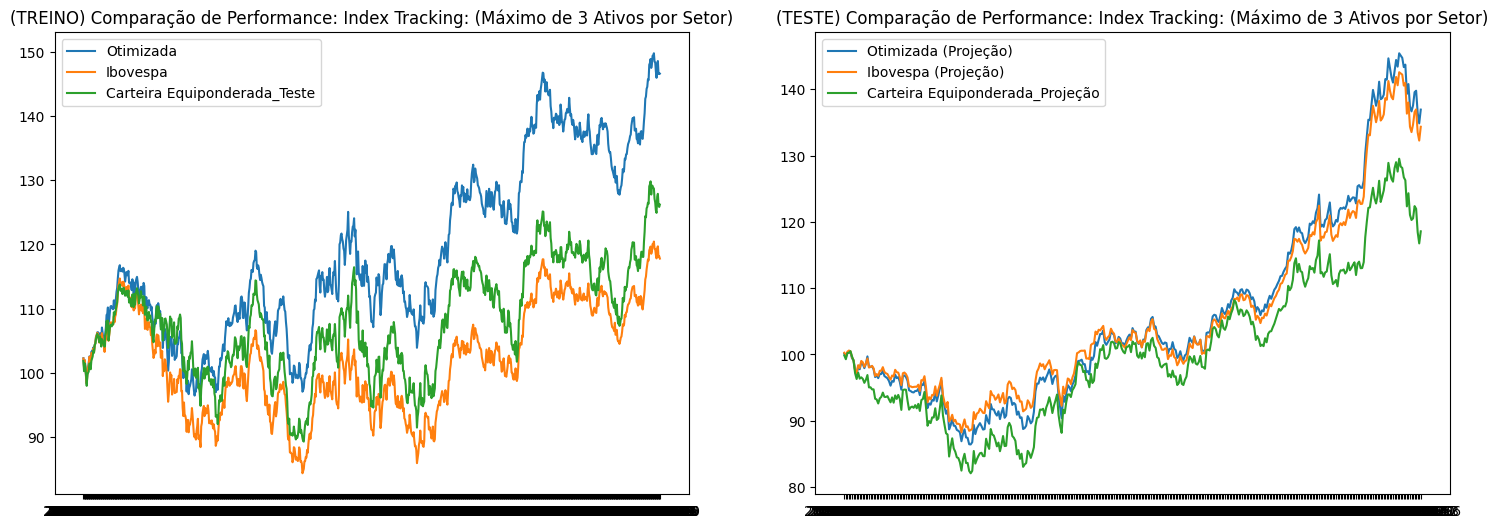

In [27]:
lista_grande = []
for ativo in model.ativos:
    peso_ativo = pyo.value(model.x[ativo])
    ativos_carteira = pyo.value(model.y[ativo])
    # print(f"Dados do Ativo: {ativo}: Peso = {pyo.value(model.x[ativo])}, y_ativo = {pyo.value(model.y[ativo])}")
    
    lista = [peso_ativo, ativos_carteira]
    lista_grande.append(lista)
    
final = pd.DataFrame(lista_grande, columns=["peso_ativo","ativado"], index=lista_ativos)
# print(final[final['ativado']==1])
df_final = final[final['ativado']==1]
# # df_final.head()
ativos_selecionados = df_final.index
retornos_carteira= df_ativos_treino[ativos_selecionados]

carteira_otimizada = (retornos_carteira*df_final['peso_ativo']).sum(axis=1)
carteira_otimizada = 1 + carteira_otimizada

carteira_equi = retornos_carteira.mean(axis=1)
carteira_equi = 1 + carteira_equi

acum_otimizado = (carteira_otimizada).cumprod() * 100
acum_equi = (carteira_equi).cumprod() * 100
acum_ibov = (1 + df_ibov_treino['IBOV']).cumprod() * 100

# carteira_equi_projecao = retornos_carteira_projecao.mean(axis=1)
# carteira_equi_projecao = 1 + carteira_equi_projecao
# 3. Transformar em Retorno Acumulado (Base 100)

# # Use os pesos que você já encontrou no modelo
# carteira_projecao = (retornos_ativo_projecao[ativos_selecionados] * df_final["peso_ativo"]).sum(axis=1)
# acum_projecao = (1 + carteira_projecao).cumprod() * 100
# acum_equi_projecao = (carteira_equi_projecao).cumprod() * 100

retornos_carteira_projecao= df_ativos_teste[ativos_selecionados]
carteira_otimizada_t= (retornos_carteira_projecao*df_final['peso_ativo']).sum(axis=1)
carteira_otimizada_treino = 1 + carteira_otimizada_t
acum_projecao_teste = carteira_otimizada_treino.cumprod() *100

acum_ibov_teste = (1 + df_ibov_teste['IBOV']).cumprod() * 100

carteira_equi_projecao = retornos_carteira_projecao.mean(axis=1)
carteira_equi_projecao = 1 + carteira_equi_projecao
acum_equi_teste = (carteira_equi_projecao).cumprod() * 100


print(acum_otimizado[-1])
print(acum_equi[-1])
print(acum_ibov[-1])

qnt_carteira = pyo.value(model.CARDINALIDADE_SETORES)
texto = f'(TREINO) Comparação de Performance: Index Tracking: (Máximo de {qnt_carteira} Ativos por Setor)'
texto_2 = f'(TESTE) Comparação de Performance: Index Tracking: (Máximo de {qnt_carteira} Ativos por Setor)'

plt.figure(figsize=(18, 6))


# Gráfico 1: Período de Treino
plt.subplot(1, 2, 1)
plt.plot(acum_otimizado, label="Otimizada")
plt.plot(acum_ibov, label="Ibovespa")
plt.plot(acum_equi, label="Carteira Equiponderada_Teste")
plt.title(texto)
plt.legend()




# Gráfico 2: Período de Projeção (Out-of-Sample)
plt.subplot(1, 2, 2)
plt.plot(acum_projecao_teste, label="Otimizada (Projeção)")
plt.plot(acum_ibov_teste, label="Ibovespa (Projeção)")
plt.plot(acum_equi_teste, label="Carteira Equiponderada_Projeção")
plt.title(texto_2)
plt.legend()

plt.show()

In [28]:
df_final = df_final.join(df_setores)

In [38]:
df_final.to_excel("teste.xlsx")

In [35]:
df_porcentagem_setor = df_final.groupby(by='Setor').sum().sort_values(by='peso_ativo' ,ascending=False)

In [36]:
df_porcentagem_setor = df_porcentagem_setor.drop(columns=['ativado']).rename(columns={'peso_ativo':'porcentagem_carteira'})
df_porcentagem_setor

,porcentagem_carteira
Setor,
Materiais_basicos,0.210721
Financeira,0.207591
Petroleo_gas_biocombustiveis,0.178348
Utilidade_publica,0.097677
Consumo_ciclico,0.070574
Consumo_nao_ciclico,0.067973
Bens_industriais,0.060545
Saude,0.045693
Comunicacoes,0.038399


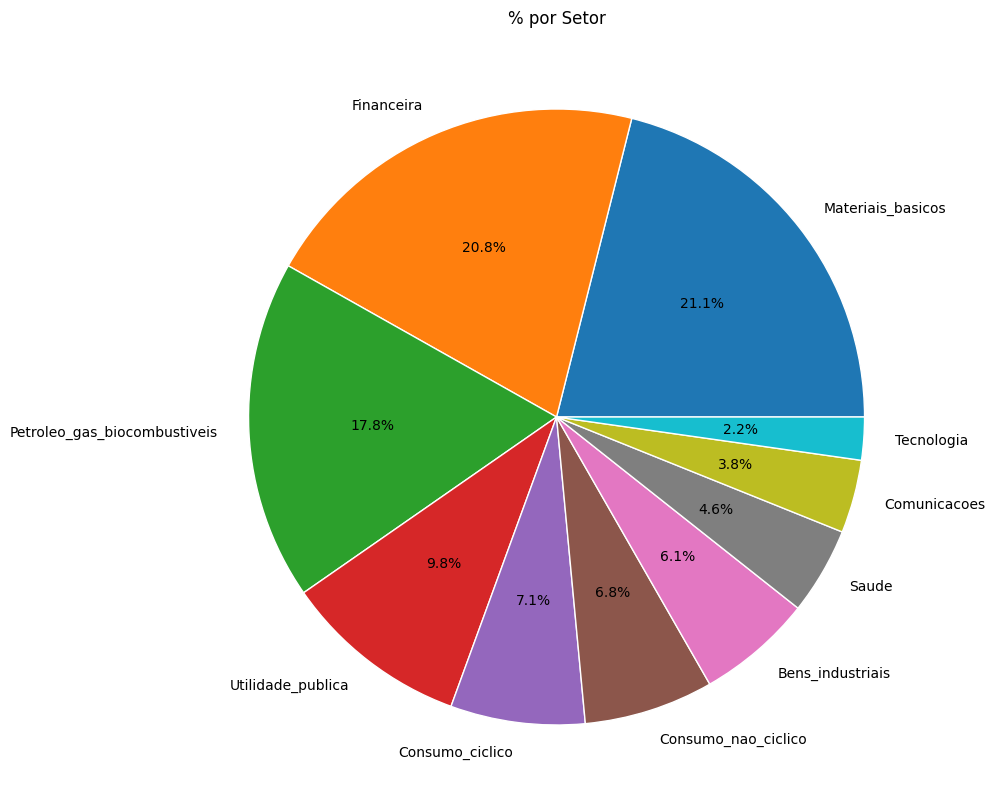

In [37]:

# plot
fig,ax= plt.subplots(figsize=(10,10))


ax.pie(df_porcentagem_setor['porcentagem_carteira'],labels=df_porcentagem_setor.index,  wedgeprops={"linewidth": 1, "edgecolor": "white"}, autopct='%1.1f%%')


ax.set_title('% por Setor')
ax.set_axis_off() 


plt.show()